In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 67.1 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO
YOLO('yolov8n-cls.pt').train(data='cifar100', epochs=50, imgsz=32, batch=128)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=128, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=cifar100, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=32, int8=False, iou=0.7, ke

ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7848cac75c70>
curves: []
curves_results: []
fitness: 0.6953499913215637
keys: ['metrics/accuracy_top1', 'metrics/accuracy_top5']
results_dict: {'metrics/accuracy_top1': 0.5582000017166138, 'metrics/accuracy_top5': 0.8324999809265137, 'fitness': 0.6953499913215637}
save_dir: PosixPath('/content/runs/classify/train')
speed: {'preprocess': 0.0028647310999986076, 'inference': 0.062097399999856855, 'loss': 4.392460041344748e-05, 'postprocess': 0.0002736616997026431}
task: 'classify'
top1: 0.5582000017166138
top5: 0.8324999809265137

In [ ]:
import torchvision
import torch
import pandas as pd
from torchvision.models import resnet18, ResNet18_Weights

# 1. 模型（启用预训练，输出层为100类）
model = resnet18(weights=ResNet18_Weights.DEFAULT)
model.fc = torch.nn.Linear(512, 100)  # CIFAR100 有 100 类
model = model.cuda()

# 2. 数据（增强对齐 YOLO 默认）
from torchvision import transforms
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

trainset = torchvision.datasets.CIFAR100(root='./data', train=True,
                                        download=True, transform=transform_train)
testset = torchvision.datasets.CIFAR100(root='./data', train=False,
                                       download=True, transform=transform_test)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=128, shuffle=False)

# 3. 优化器（AdamW 对齐 YOLO）
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.05)
criterion = torch.nn.CrossEntropyLoss()

# ===== 记录结果的列表 =====
train_losses = []
test_accs = []

# 4. 训练循环
for epoch in range(50):
    # 训练
    model.train()
    running_loss = 0.0
    for inputs, labels in trainloader:
        inputs, labels = inputs.cuda(), labels.cuda()

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(trainloader)
    train_losses.append(avg_loss)

    # ===== 每个epoch后测试准确率 =====
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.cuda(), labels.cuda()
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    acc = 100 * correct / total
    test_accs.append(acc)

    print(f'Epoch {epoch+1}, Loss: {avg_loss:.4f}, Acc: {acc:.2f}%')

# ===== 保存结果 =====
torch.save(model.state_dict(), 'resnet18_cifar100_fair.pth')
print(f"✅ 模型已保存: resnet18_cifar100_fair.pth")

results_df = pd.DataFrame({
    'epoch': range(1, 51),
    'train_loss': train_losses,
    'test_acc': test_accs
})
results_df.to_csv('resnet18_results_cifar100_fair.csv', index=False)
print(f"✅ 结果已保存: resnet18_results_cifar100_fair.csv")

print(f"\n📊 最终结果:")
print(f"最佳准确率: {max(test_accs):.2f}%")
print(f"最终准确率: {test_accs[-1]:.2f}%")

Epoch 1, Loss: 3.1159, Acc: 34.09%
Epoch 2, Loss: 2.4055, Acc: 41.10%
Epoch 3, Loss: 2.1736, Acc: 44.28%
Epoch 4, Loss: 2.0285, Acc: 46.85%
Epoch 5, Loss: 1.9140, Acc: 49.01%
Epoch 6, Loss: 1.8224, Acc: 49.73%
Epoch 7, Loss: 1.7634, Acc: 50.83%
Epoch 8, Loss: 1.6889, Acc: 51.86%
Epoch 9, Loss: 1.6390, Acc: 52.13%
Epoch 10, Loss: 1.5845, Acc: 53.11%
Epoch 11, Loss: 1.5448, Acc: 53.29%
Epoch 12, Loss: 1.4872, Acc: 52.22%
Epoch 13, Loss: 1.4546, Acc: 54.42%
Epoch 14, Loss: 1.4245, Acc: 53.71%
Epoch 15, Loss: 1.4011, Acc: 54.35%
Epoch 16, Loss: 1.3480, Acc: 54.26%
Epoch 17, Loss: 1.3134, Acc: 55.47%
Epoch 18, Loss: 1.2797, Acc: 56.46%
Epoch 19, Loss: 1.2643, Acc: 56.07%
Epoch 20, Loss: 1.2289, Acc: 56.61%
Epoch 21, Loss: 1.1928, Acc: 55.97%
Epoch 22, Loss: 1.1733, Acc: 55.95%
Epoch 23, Loss: 1.1409, Acc: 55.09%
Epoch 24, Loss: 1.1179, Acc: 54.97%
Epoch 25, Loss: 1.0917, Acc: 57.77%
Epoch 26, Loss: 1.0744, Acc: 55.90%
Epoch 27, Loss: 1.0479, Acc: 55.48%
Epoch 28, Loss: 1.0144, Acc: 56.65%
E

YOLO准确率范围: 21.11% - 55.77%
ResNet准确率范围: 34.09% - 57.77%


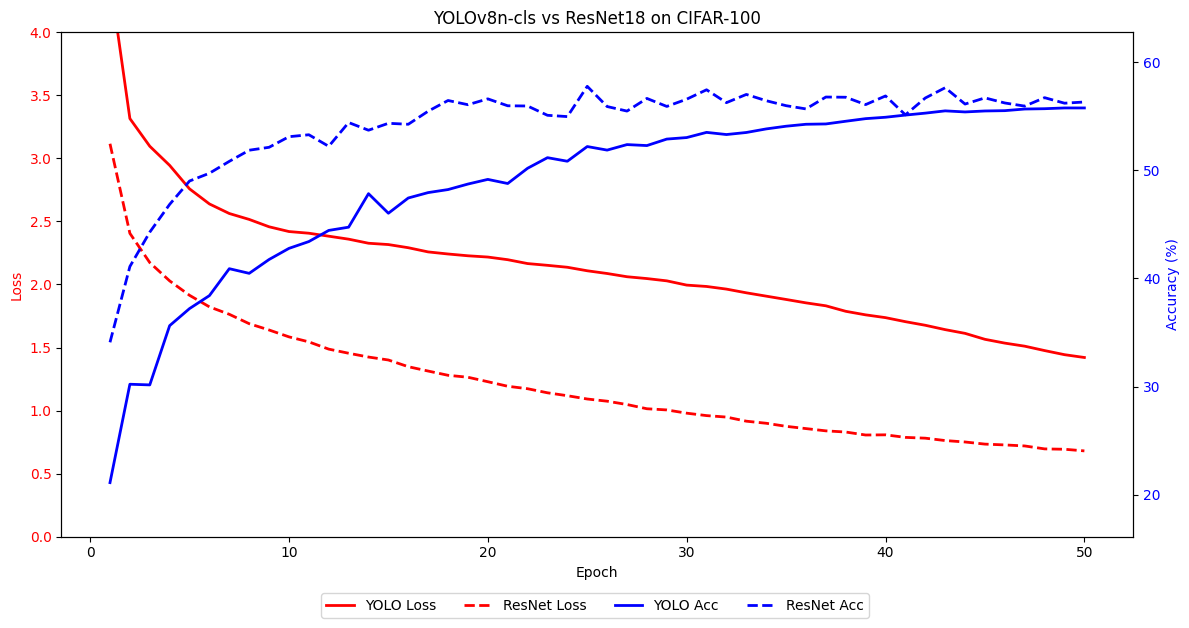

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 读取数据
yolo = pd.read_csv('/content/runs/classify/train/results.csv')
resnet = pd.read_csv('resnet18_results_cifar100_fair.csv')

# 打印数据范围检查
print(f"YOLO准确率范围: {yolo['metrics/accuracy_top1'].min()*100:.2f}% - {yolo['metrics/accuracy_top1'].max()*100:.2f}%")
print(f"ResNet准确率范围: {resnet['test_acc'].min():.2f}% - {resnet['test_acc'].max():.2f}%")

fig, ax1 = plt.subplots(figsize=(12, 6))

# 左轴 - 损失
ax1.plot(yolo['epoch'], yolo['train/loss'], 'r-', linewidth=2, label='YOLO Loss')
ax1.plot(resnet['epoch'], resnet['train_loss'], 'r--', linewidth=2, label='ResNet Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss', color='r')
ax1.tick_params(axis='y', labelcolor='r')
ax1.set_ylim(0, 4)

# 右轴 - 准确率
ax2 = ax1.twinx()
ax2.plot(yolo['epoch'], yolo['metrics/accuracy_top1']*100, 'b-', linewidth=2, label='YOLO Acc')
ax2.plot(resnet['epoch'], resnet['test_acc'], 'b--', linewidth=2, label='ResNet Acc')
ax2.set_ylabel('Accuracy (%)', color='b')
ax2.tick_params(axis='y', labelcolor='b')

# 自动调整Y轴范围，确保所有数据可见
yolo_min = yolo['metrics/accuracy_top1'].min()*100
yolo_max = yolo['metrics/accuracy_top1'].max()*100
resnet_min = resnet['test_acc'].min()
resnet_max = resnet['test_acc'].max()

ax2.set_ylim(min(yolo_min, resnet_min)-5, max(yolo_max, resnet_max)+5)

plt.title('YOLOv8n-cls vs ResNet18 on CIFAR-100')

# 图例
fig.legend(loc='lower center', bbox_to_anchor=(0.5, -0.05), ncol=4)
plt.tight_layout()
plt.savefig('comparison_cifar100.png', dpi=300, bbox_inches='tight')
plt.show()